Import necessary libraries

In [28]:
library(dplyr)
library(censusapi)

library(usmap)
library(ggplot2)

Load in county level poverty data from the 2023 5-year American Community Survey. Specifically, the estimate for the population living in poverty and the percent of the population living in poverty.

In [ ]:
acs_subject <- getCensus(
    name = "acs/acs5/subject",
    vintage = 2023, 
    vars = c(
        "NAME",
        "S1701_C01_001E", # Estimate!!Total!!Population for whom poverty status is determined
        "S1701_C03_001E"  # Estimate!!Percent below poverty level!!Population for whom poverty status is determined
        ), 
    region = "county:*",
    regionin = "state:10,11,12,13,24,37,45,51,54") # South Atlantic states
nrow(acs_subject)
acs_subject %>% arrange(S1701_C03_001E) %>% head()

[1] 588

,state,county,NAME,S1701_C01_001E,S1701_C03_001E
,<chr>,<chr>,<chr>,<int>,<dbl>
1,51,145,"Powhatan County, Virginia",29520,3.3
2,51,610,"Falls Church city, Virginia",14518,3.6
3,51,075,"Goochland County, Virginia",24636,3.9
4,24,009,"Calvert County, Maryland",93318,4.0
5,51,107,"Loudoun County, Virginia",424861,4.0
6,13,117,"Forsyth County, Georgia",258953,4.5


Break percent of population in poverty statistics into 5 brackets each of 5% widths.

In [57]:
acs_subject <- acs_subject %>% 
    mutate(
    fips = paste0(state, county), 
    bracket = case_when(
        S1701_C03_001E < 5 ~ "<5%",
        S1701_C03_001E >= 5 & S1701_C03_001E < 10 ~ "5-9.9%",
        S1701_C03_001E >= 10 & S1701_C03_001E < 15 ~ "10-14.9%",
        S1701_C03_001E >= 15 & S1701_C03_001E < 20 ~ "15-19.9%",
        S1701_C03_001E >= 20 ~ "20%+"
        ),
    bracket = factor(bracket, levels = c("<5%", "5-9.9%", "10-14.9%", "15-19.9%", "20%+"))
    )

Plot the South Atlantic region using `usmap` library.

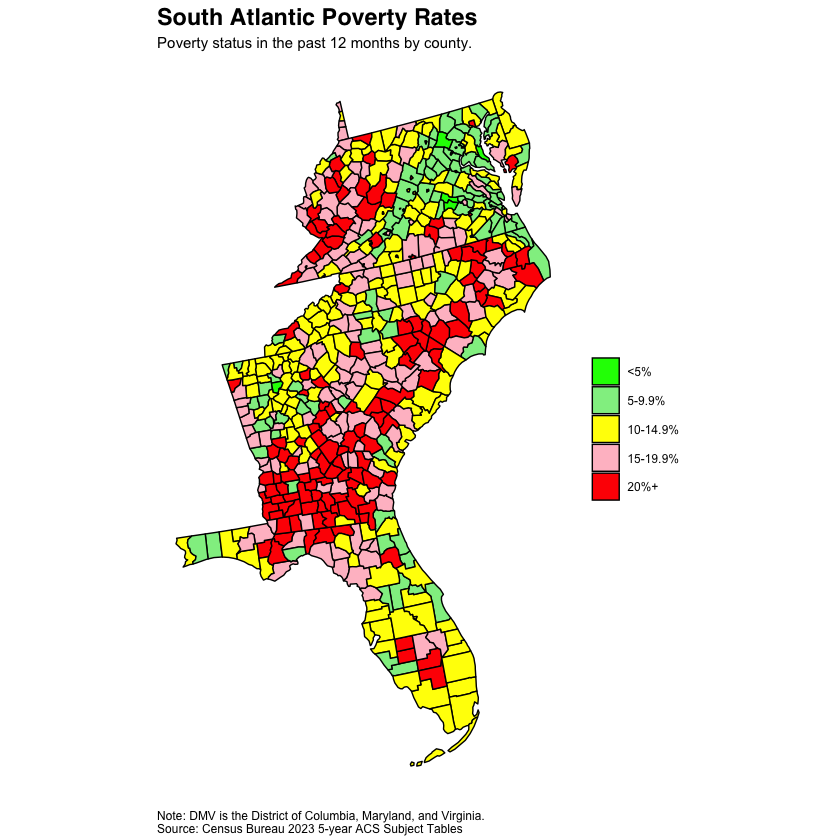

In [62]:
dmv_poverty <- plot_usmap("counties", include = .south_atlantic, data = acs_subject, values = "bracket") +
  scale_fill_manual(
    name = NULL,
    values = c(
      "<5%" = "green",
      "5-9.9%" = "lightgreen",
      "10-14.9%" = "yellow",
      "15-19.9%" = "pink",
      "20%+" = "red"
    )
  ) +
  labs(
    title = "South Atlantic Poverty Rates",
    subtitle = "Poverty status in the past 12 months by county.",
    caption = 'Note: DMV is the District of Columbia, Maryland, and Virginia.\nSource: Census Bureau 2023 5-year ACS Subject Tables'
       ) + 
  theme(
    panel.background=element_blank(),
    legend.position = "right",
    plot.caption = element_text(hjust = 0),
    plot.title = element_text(family = "Helvetica", face = "bold", size = 14)
    )

  dmv_poverty

Save plot as .png

In [59]:
ggsave(
  "../plots/dmv_poverty.png",
  plot = dmv_poverty,
  width = 3.9,
  height = 3.2*1.5,
  units = "in",
  dpi = 300,
  bg = "white"
)

Check which states are included in pre-defined regions and which states are associated with which FIPS code for the Census Bureau's API call above.

Warning message in get_fips_info(fips_, sortAndRemoveDuplicates, data_year = data_year):
“FIPS code(s) 03, 07, 14, 43, 52 not found”


,abbr,fips,full
,<chr>,<chr>,<chr>
1,AL,01,Alabama
2,AK,02,Alaska
3,AZ,04,Arizona
4,AR,05,Arkansas
5,CA,06,California
6,CO,08,Colorado


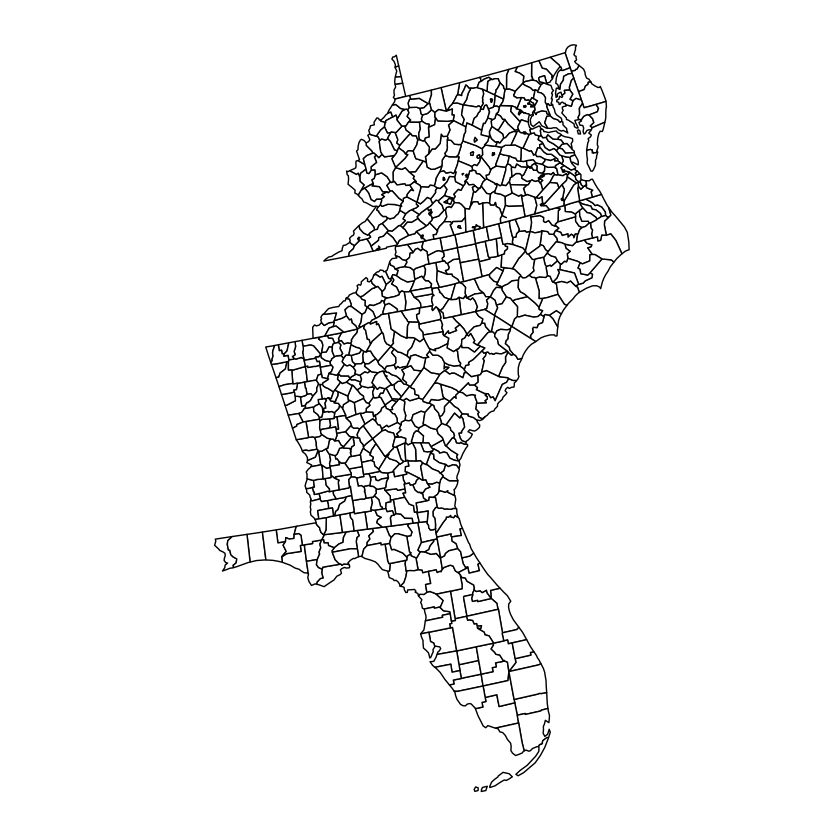

In [ ]:
plot_usmap("counties", .south_atlantic)
head(fips_info(1:56))